In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks 
from scipy.optimize import curve_fit

plt.style.use("seaborn-v0_8")

fontsize = 15
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": fontsize,
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fontsize": fontsize,
        "mathtext.default": "regular",
        "mathtext.fontset": "cm",
        "legend.frameon": True,
    }
)

         Tiempo  VoltajeCH1  ResolucionVCH1
0 -1.000000e-06       0.004           0.002
1 -9.960000e-07       0.006           0.002
2 -9.920000e-07       0.000           0.002
3 -9.880000e-07       0.002           0.002
4 -9.840000e-07       0.004           0.002


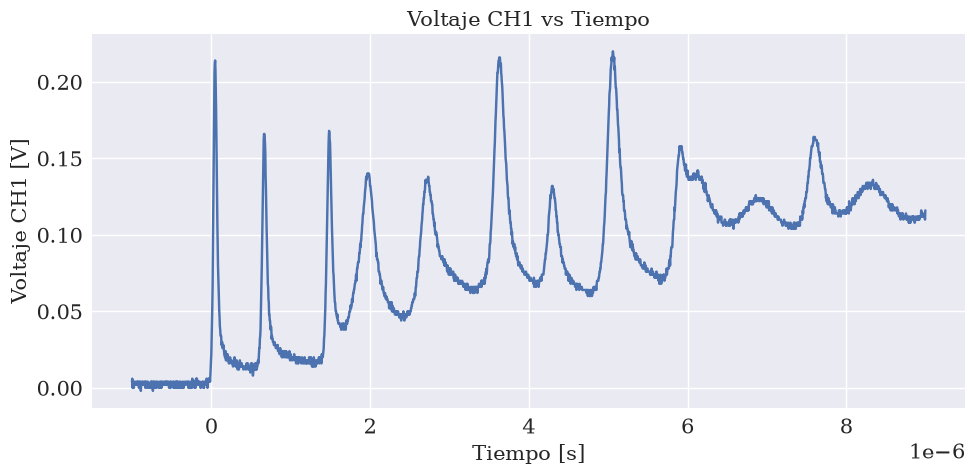

In [23]:
L = 6.2 # Largo cavidad cm
f = 610 # Frecuancia Hz
p = 2.38 # potencia (corriente al laser en A)
ventana= "s" # p: pico, s: subida o v: , pc:  pulso completo 
counter = 1 # nro de medicion

L_text = f"_L{L:.1f}" if L != 6.2 else ""
nombre_archivo = f"laser_chopper{L_text}_f{f:.0f}_p{p:.2f}_{ventana}_{counter}.csv"

ruta = "../datos/" + nombre_archivo

# Importar el CSV


df = pd.read_csv(ruta)

# Mostrar las primeras filas
print(df.head())

# Graficar VoltajeCH1 en función de Tiempo
plt.figure(figsize=(10, 5))
plt.plot(df["Tiempo"], df["VoltajeCH1"])

plt.xlabel("Tiempo [s]")
plt.ylabel("Voltaje CH1 [V]")
plt.title("Voltaje CH1 vs Tiempo")
plt.grid(True)

plt.tight_layout()
plt.show()

4 picos encontrados para L = 6.2 corrida 1


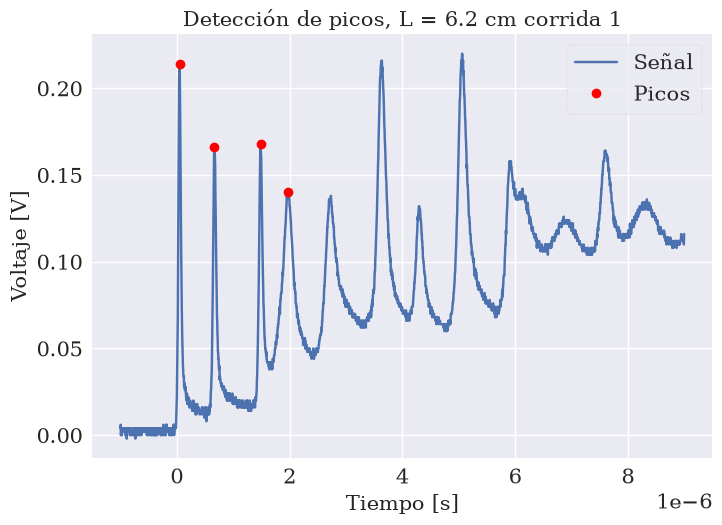

4 picos encontrados para L = 13.5 corrida 1


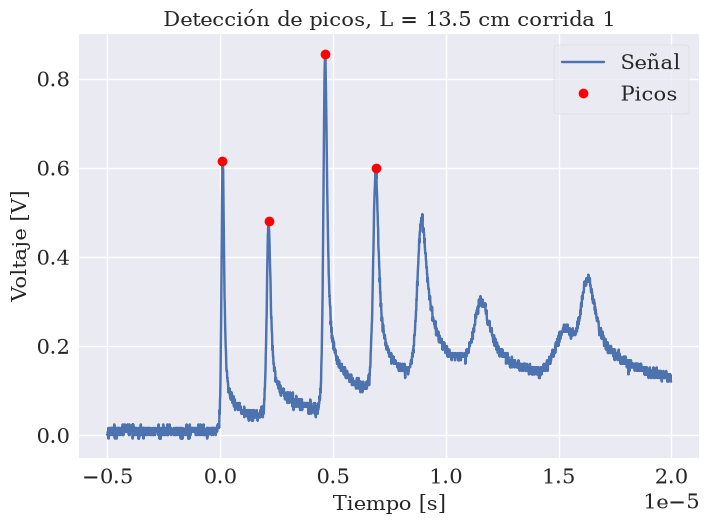

3 picos encontrados para L = 21.4 corrida 1


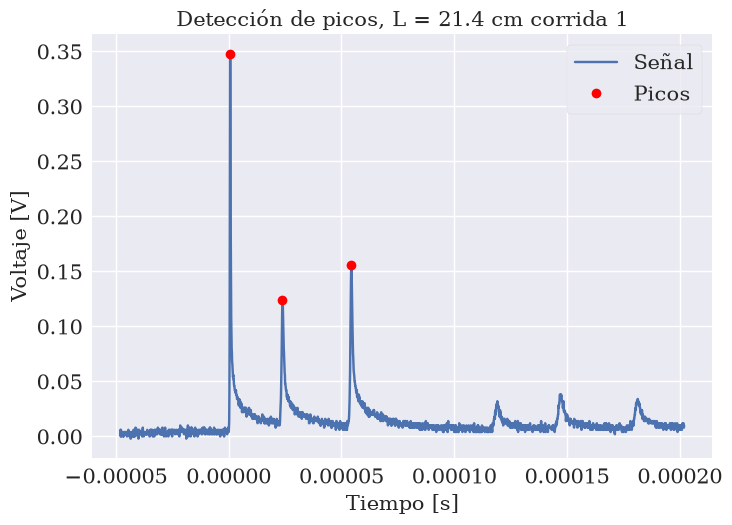

4 picos encontrados para L = 87.0 corrida 1


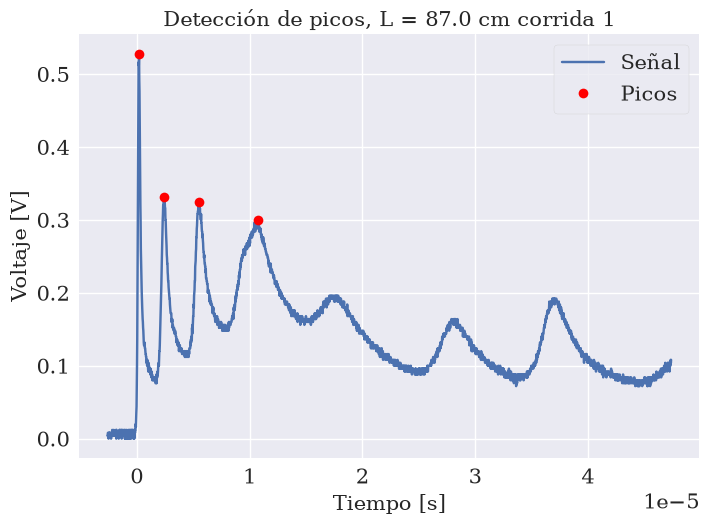

4 picos encontrados para L = 6.2 corrida 2


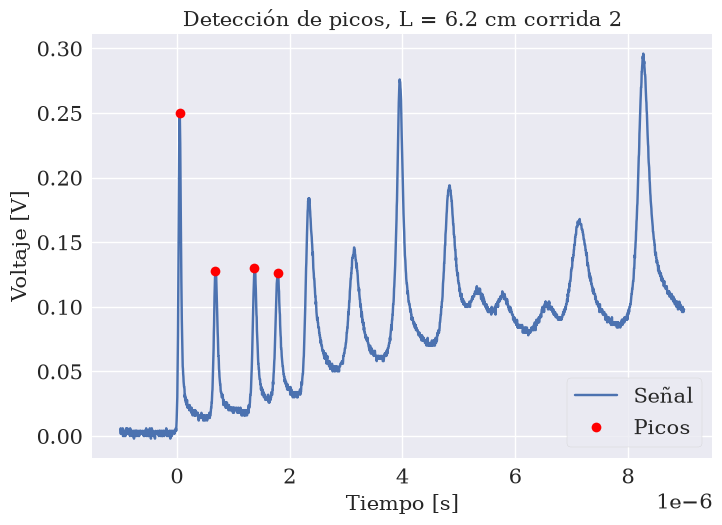

4 picos encontrados para L = 13.5 corrida 2


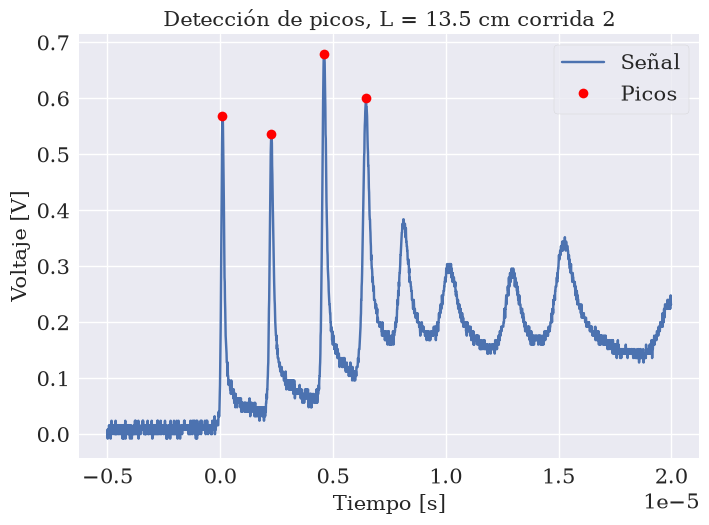

3 picos encontrados para L = 21.4 corrida 2


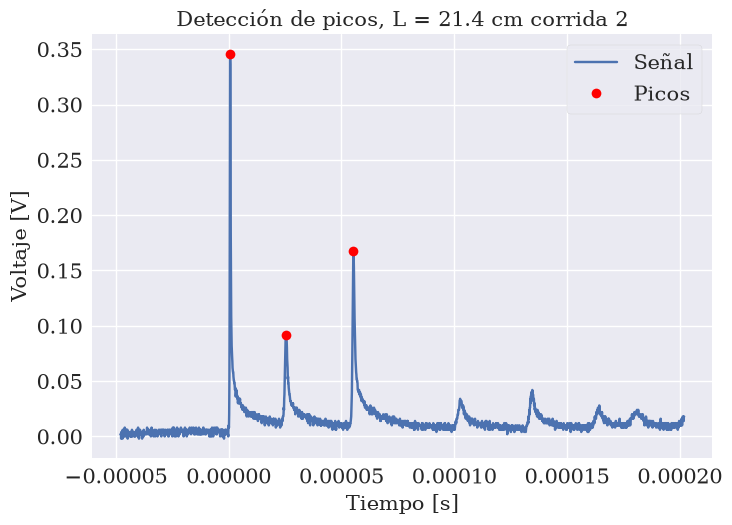

4 picos encontrados para L = 87.0 corrida 2


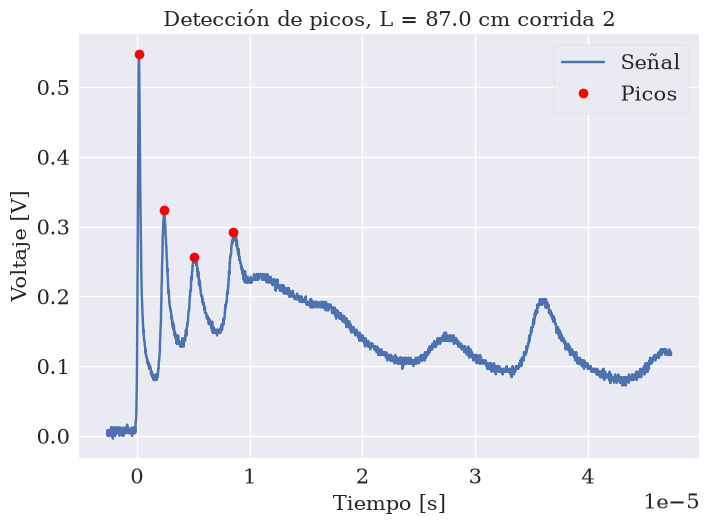

4 picos encontrados para L = 6.2 corrida 3


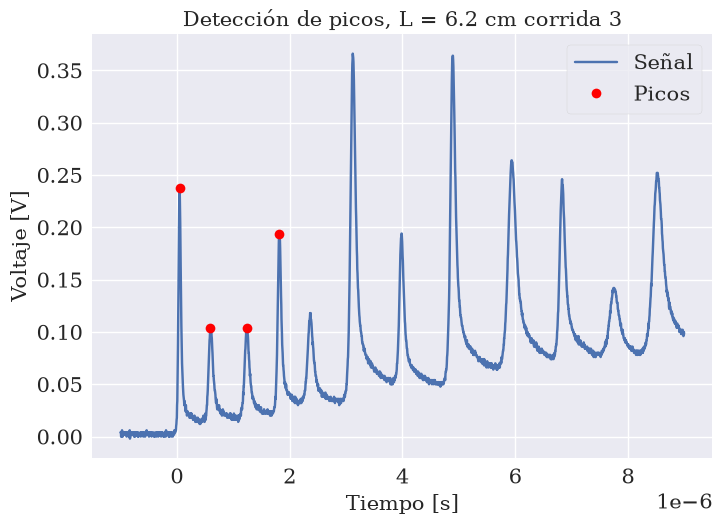

4 picos encontrados para L = 13.5 corrida 3


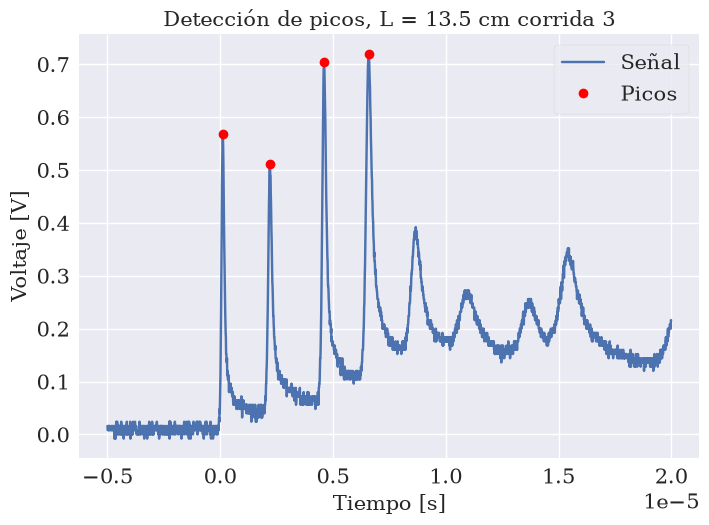

3 picos encontrados para L = 21.4 corrida 3


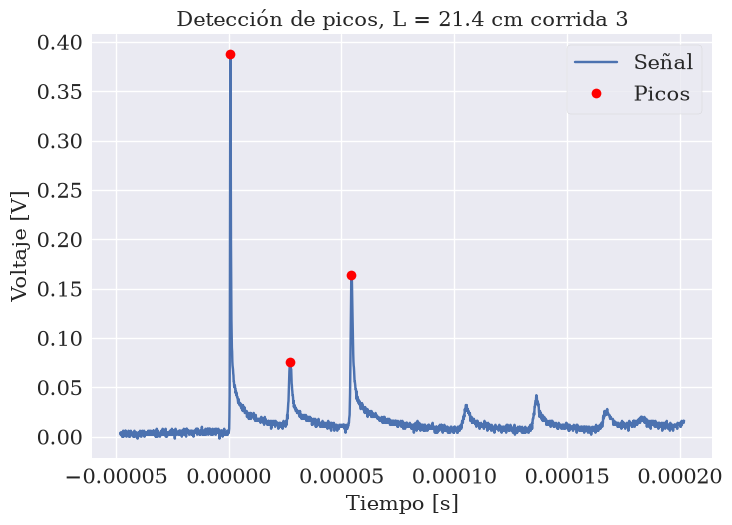

4 picos encontrados para L = 87.0 corrida 3


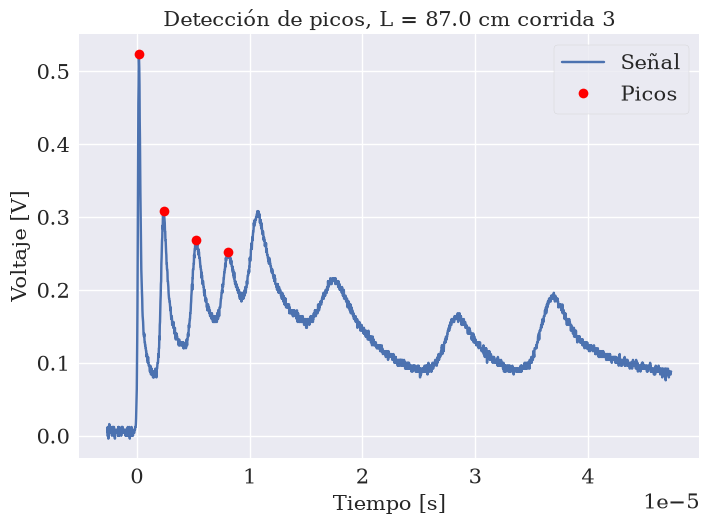

       L                                 archivo      dt_medio        dt_std
0    6.2        laser_chopper_f610_p2.38_s_1.csv  6.413333e-07  1.367171e-07
1   13.5  laser_chopper_L13.5_f610_p2.38_s_1.csv  2.266667e-06  1.922383e-07
2   21.4  laser_chopper_L21.4_f610_p2.38_s_1.csv  2.690000e-05  3.700000e-06
3   87.0  laser_chopper_L87.0_f610_p2.38_s_1.csv  3.506667e-06  1.238960e-06
4    6.2        laser_chopper_f610_p2.38_s_2.csv  5.813333e-07  1.191227e-07
5   13.5  laser_chopper_L13.5_f610_p2.38_s_2.csv  2.120000e-06  1.899123e-07
6   21.4  laser_chopper_L21.4_f610_p2.38_s_2.csv  2.735000e-05  2.550000e-06
7   87.0  laser_chopper_L87.0_f610_p2.38_s_2.csv  2.786667e-06  5.167419e-07
8    6.2        laser_chopper_f610_p2.38_s_3.csv  5.893333e-07  4.030991e-08
9   13.5  laser_chopper_L13.5_f610_p2.38_s_3.csv  2.156667e-06  1.778264e-07
10  21.4  laser_chopper_L21.4_f610_p2.38_s_3.csv  2.685000e-05  4.500000e-07
11  87.0  laser_chopper_L87.0_f610_p2.38_s_3.csv  2.626667e-06  3.034615e-07

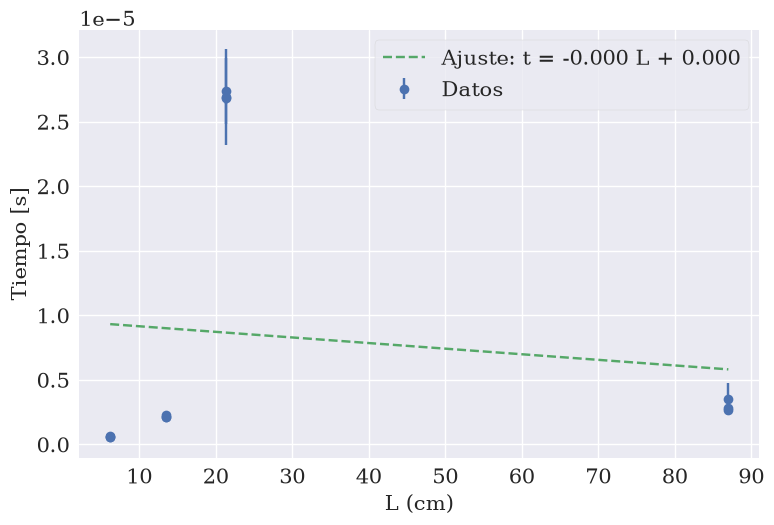

-4.61e+05 m/s


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks 

configs = np.concatenate([[
    {"L": 6.2,  "f": 610, "p": 2.38, "ventana": "s", "counter": counter},
    {"L": 13.5, "f": 610, "p": 2.38, "ventana": "s", "counter": counter},
    {"L": 21.4, "f": 610, "p": 2.38, "ventana": "s", "counter": counter},
    {"L": 87.0, "f": 610, "p": 2.38, "ventana": "s", "counter": counter},
] for counter in range(1, 4)])

FIND_PEAKS_KWARGS = dict(
    height=None,
    distance=100,
    prominence=0.05,
)

PLOT_SERIES = True # plotear cada serie de tiempo y los picos detectados

N_PICOS = 4 # Tomar hasta los primeros N_PICOS picos de cada serie

def nombre_archivo(cfg):
    L_text = f"_L{cfg['L']:.1f}" if cfg["L"] != 6.2 else ""
    return f"laser_chopper{L_text}_f{cfg['f']:.0f}_p{cfg['p']:.2f}_{cfg['ventana']}_{cfg['counter']}.csv"


def tiempo_medio_entre_picos(t, v, L, counter, plot = False, **kwargs):
    """Encuentra los picos de v(t) y devuelve (dt_medio, dt_std) entre picos consecutivos."""
    idx_picos, _ = find_peaks(v, **kwargs)
    idx_picos = idx_picos[:N_PICOS]
    print(len(idx_picos), "picos encontrados para L =", L, "corrida", counter)
    if len(idx_picos) < 2:
        return np.nan, np.nan
    t_picos = t[idx_picos]
    dt = np.diff(t_picos)
    if plot:
        plt.plot(t, v, label="Señal")
        plt.plot(t_picos, v[idx_picos], "o", color = "red", label="Picos")
        plt.xlabel("Tiempo [s]")
        plt.ylabel("Voltaje [V]")
        plt.legend()
        plt.title(f"Detección de picos, L = {L:.1f} cm corrida {counter}")
        plt.show()
    return dt.mean(), dt.std()


# ---------------------------------------------------------------------------
# Loop principal: cargar cada archivo y calcular el tiempo medio entre picos
# ---------------------------------------------------------------------------
resultados = []

for cfg in configs:
    ruta = "../datos/" + nombre_archivo(cfg)
    df = pd.read_csv(ruta)

    t = df["Tiempo"].to_numpy()
    v = df["VoltajeCH1"].to_numpy()

    dt_medio, dt_std = tiempo_medio_entre_picos(t, v, cfg["L"], cfg["counter"], plot = PLOT_SERIES, **FIND_PEAKS_KWARGS)

    resultados.append(
        {
            "L": cfg["L"],
            "archivo": nombre_archivo(cfg),
            "dt_medio": dt_medio,
            "dt_std": dt_std,
        }
    )

res_df = pd.DataFrame(resultados)
print(res_df)

res_df = res_df.dropna(subset=["dt_medio"])
if res_df.empty:
    raise RuntimeError("No se encontraron suficientes picos en ningún archivo; revisar FIND_PEAKS_KWARGS.")

# ---------------------------------------------------------------------------
# Ajuste lineal dt_medio en función de L
# ---------------------------------------------------------------------------
L_arr = res_df["L"].to_numpy()
time_arr = res_df["dt_medio"].to_numpy()
time_err = res_df["dt_std"].to_numpy() 

m, b = np.polyfit(L_arr, time_arr, 1)

L_fit = np.linspace(L_arr.min(), L_arr.max(), 200)
time_fit = m * L_fit + b

fig, ax = plt.subplots()
ax.errorbar(L_arr, time_arr, yerr=time_err, fmt="o", label="Datos", capsize=3)
ax.plot(L_fit, time_fit, "--", label=f"Ajuste: t = {m:.3f} L + {b:.3f}")
ax.set_xlabel("L (cm)")
ax.set_ylabel("Tiempo [s]")
ax.legend()
plt.tight_layout()

print(f"\nPendiente: {m}")
print(f"Ordenada al origen: {b}")
plt.show()

c = 2/m / 100
print(f"{c:.2e} m/s")

       f    L     p ventana  counter                            archivo  v_max
0    186  6.2  2.38       s        1   laser_chopper_f186_p2.38_s_1.csv  0.104
1    305  6.2  2.38       s        1   laser_chopper_f305_p2.38_s_1.csv  0.172
2    610  6.2  2.38       s        1   laser_chopper_f610_p2.38_s_1.csv  0.220
3   1000  6.2  2.38       s        1  laser_chopper_f1000_p2.38_s_1.csv  0.384
4    186  6.2  2.38       s        2   laser_chopper_f186_p2.38_s_2.csv  0.092
5    305  6.2  2.38       s        2   laser_chopper_f305_p2.38_s_2.csv  0.224
6    610  6.2  2.38       s        2   laser_chopper_f610_p2.38_s_2.csv  0.296
7   1000  6.2  2.38       s        2  laser_chopper_f1000_p2.38_s_2.csv  0.412
8    186  6.2  2.38       s        3   laser_chopper_f186_p2.38_s_3.csv  0.096
9    305  6.2  2.38       s        3   laser_chopper_f305_p2.38_s_3.csv  0.236
10   610  6.2  2.38       s        3   laser_chopper_f610_p2.38_s_3.csv  0.366
11  1000  6.2  2.38       s        3  laser_chopper_

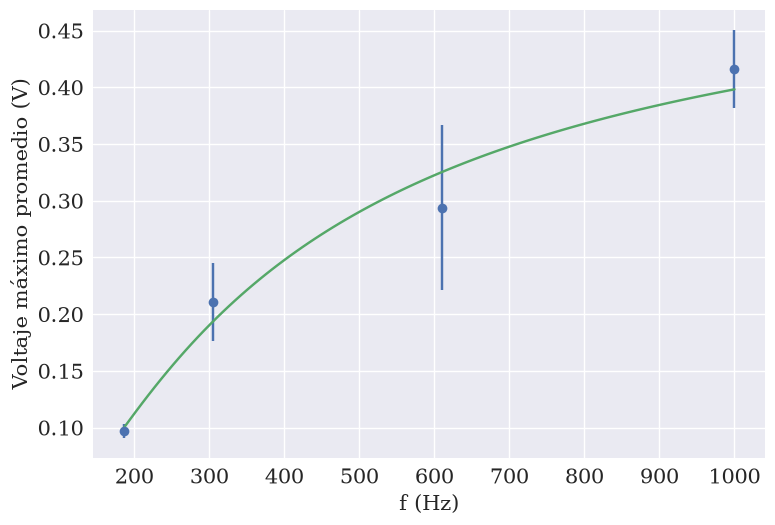

In [34]:
configs = np.concatenate([[
    {"L": 6.2,  "f": 186, "p": 2.38, "ventana": "s", "counter": counter},
    {"L": 6.2, "f": 305, "p": 2.38, "ventana": "s", "counter": counter},
    {"L": 6.2, "f": 610, "p": 2.38, "ventana": "s", "counter": counter},
    {"L": 6.2, "f": 1000, "p": 2.38, "ventana": "s", "counter": counter},
] for counter in range(1, 4)])

def nombre_archivo(cfg):
    L_text = f"_L{cfg['L']:.1f}" if cfg["L"] != 6.2 else ""
    return f"laser_chopper{L_text}_f{cfg['f']:.0f}_p{cfg['p']:.2f}_{cfg['ventana']}_{cfg['counter']}.csv"

def exponencial_inv(f, A, f_0):
    return A * np.exp(-f_0/f)

# ---------------------------------------------------------------------------
# Loop principal: cargar cada archivo y calcular el voltaje máximo
# ---------------------------------------------------------------------------
resultados = []

for cfg in configs:
    ruta = "../datos/" + nombre_archivo(cfg)
    df = pd.read_csv(ruta)

    v_max = df["VoltajeCH1"].max()

    resultados.append(
        {
            "f": cfg["f"],
            "L": cfg["L"],
            "p": cfg["p"],
            "ventana": cfg["ventana"],
            "counter": cfg["counter"],
            "archivo": nombre_archivo(cfg),
            "v_max": v_max,
        }
    )

res_df = pd.DataFrame(resultados)
print(res_df)

# ---------------------------------------------------------------------------
# Promediar v_max sobre todas las corridas que comparten el mismo f
# ---------------------------------------------------------------------------
promedios = (
    res_df.groupby("f")["v_max"]
    .agg(v_max_medio="mean", v_max_std="std", n="count")
    .reset_index()
    .sort_values("f")
)

print("\nPromedio de voltaje máximo por frecuencia:")
print(promedios)

# ---------------------------------------------------------------------------
# Gráfico
# ---------------------------------------------------------------------------
fig, ax = plt.subplots()
ax.errorbar(
    promedios["f"],
    promedios["v_max_medio"],
    yerr=promedios["v_max_std"].fillna(0),
    fmt="o",
    capsize=3,
)
popt, pcov = curve_fit(exponencial_inv, promedios["f"], promedios["v_max_medio"])
fs = np.linspace(np.min(promedios["f"]), np.max(promedios["f"]), 100)
ax.plot(fs, exponencial_inv(fs, *popt), label=f"Ajuste: V = {popt[0]:.3f} f^{popt[1]:.3f}")
ax.set_xlabel("f (Hz)")
ax.set_ylabel("Voltaje máximo promedio (V)")

plt.tight_layout()
plt.show()